In [1]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt

The model is A+B<->C. It will compare the simulation and theory in a non-spatial model in 3D.

Note: Simulation takes 4mins 20s on macbook m3 pro.

In [2]:
! ../../bin/nerdss -f parms3d.inp > OUTPUT 

In [3]:
# Model definition
volume = 939.993 ** 3 #nm**3
nA0 = 1000
nB0 = 1000
A0 = nA0/volume/0.602*10**6 # uM
B0 = nB0/volume/0.602*10**6 # uM
kon = 300 #/uM/s
koff = 50 #/s
time = np.logspace(-7,0,num=500) #s

In [4]:
# Theoretical Solution for reversible binding distinct reactants
def theo_solu(koff, kon, A0, B0, time, volume):
    q0 = koff*A0
    q1 = -kon*(B0-A0)- koff
    q2 = -kon
    r1 = (q1+np.sqrt(q1**2-4*q0*q2))/2
    r2 = (q1-np.sqrt(q1**2-4*q0*q2))/2
    lam = (r2+A0*q2)/(r1+A0*q2)
    At = 1 / q2*(lam*r1*np.exp(r1*time)-r2*np.exp(r2*time))/(np.exp(r2*time)-lam*np.exp(r1*time))
    At_copies = At * volume * 0.602/10**6
    return At_copies

At_copies = theo_solu(koff, kon, A0, B0, time, volume)  

In [5]:
# Calculate Equilibrium for 
keq = kon/koff
a = 1
b = (B0-A0) + 1/keq
c = A0/keq
Aeq = -b/2+np.sqrt(b**2+4*c*a)/2
Aeq_copies = Aeq * volume * 0.602/10**6

Aeq_copies

np.float64(250.00008520254588)

In [6]:
import pandas as pd

df = pd.read_csv('DATA/copy_numbers_time.dat')

df

,Time (s),A(a),R(r),A(a!1).R(r!1)
0,0.00000,1000,1000,0
1,0.00002,991,991,9
2,0.00004,980,980,20
3,0.00006,970,970,30
4,0.00008,953,953,47
...,...,...,...,...
3496,0.06992,256,256,744
3497,0.06994,256,256,744
3498,0.06996,256,256,744
3499,0.06998,257,257,743


(0.0, 1200.0)

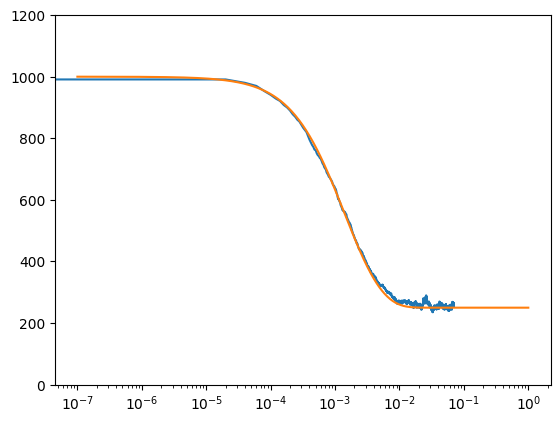

In [7]:
plt.semilogx(df['Time (s)'],df['A(a)'])
plt.semilogx(time,At_copies)
plt.ylim([0,1200])

In [8]:
df_time_greater_003 = df['Time (s)'] > 0.03

df_time_greater_003

0       False
1       False
2       False
3       False
4       False
        ...  
3496     True
3497     True
3498     True
3499     True
3500     True
Name: Time (s), Length: 3501, dtype: bool

In [9]:
Aeq_sim = df['A(a)'][df_time_greater_003].mean()
Aeq_sim

np.float64(252.9095)

In [10]:
err = abs(Aeq_copies - Aeq_sim)/Aeq_copies*100
err

np.float64(1.163765522358512)

In [11]:
if err > 10:
    print('Error! equilibrium greater than 10%.')
elif err > 3:
    print('Warning! Equilibrium error (greater than 3%), test more trajectories.')
else:
    print('Equilibrium is accurate. Error = ' + str(round(err,2)) + '%')

Equilibrium is accurate. Error = 1.16%


In [37]:
time_sim = df['Time (s)']
At_theory = theo_solu(koff, kon, A0, B0, time_sim, volume)
At_theory

0       1000.000000
1        988.148205
2        976.585757
3        965.302460
4        954.288593
           ...     
3496     250.000085
3497     250.000085
3498     250.000085
3499     250.000085
3500     250.000085
Name: Time (s), Length: 3501, dtype: float64

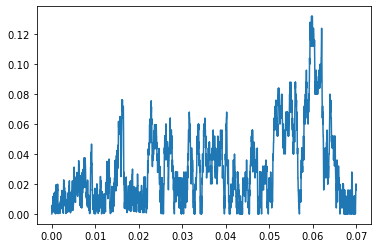

In [51]:
# quantify the error of time resolved kinetics

df_err = abs((At_theory - df['A(a)'])/At_theory)

plt.plot(time_sim, df_err)

In [59]:
df_err_greater_01 = df_err > 0.1

percent_err = df_err_greater_01.sum()/len(df_err_greater_01)*100

if percent_err > 5:
    print('Error! Kinetics does not macth! (greater than 5%). The error is ' + str(round(percent_err, 2)) + '%')
elif percent_err > 2:
    print('Warning! Error in the kinetics. The error is ' + str(round(percent_err, 2)) + '%')
else:
    print('Kinetics is accurate. The error is ' + str(round(percent_err, 2)) + '%')

Kinetics is accurate. The error is 1.86%


(0.0, 1200.0)

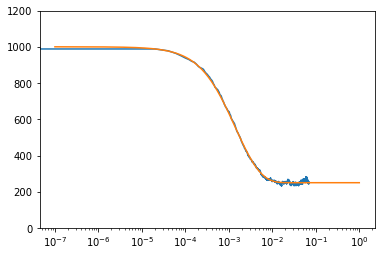

In [60]:
plt.semilogx(df['Time (s)'],df['A(a)'])
plt.semilogx(time,At_copies)
plt.ylim([0,1200])

In [ ]:
def literation_equi():